https://huggingface.co/docs/transformers/v4.42.0/ja/tasks/object_detection
こちらも、入力画像のりサイズ時に、元画像のアスペクト比を維持して、
余白には、黒(0,0,0) を埋めるようにしました。by nishi 2026.3.17

In [1]:
from huggingface_hub import notebook_login
notebook_login()

In [2]:
import numpy as np
import os
from PIL import Image, ImageDraw

#### class が、 4 個になったので、下記のように、記述します。
'category': datasets.ClassLabel(names=['zasou', 'tree', 'potted_plant','zasou_cluster'], id=None)

In [3]:
import datasets
# datsets.Featuresを定義
my_features = datasets.Features(
{ 'image': datasets.Image(mode=None, decode=True, id=None),
 'img_sub_path': datasets.Value(dtype='string', id=None),
 'image_id': datasets.Value(dtype='int64', id=None),
 'width': datasets.Value(dtype='int32', id=None),
 'height': datasets.Value(dtype='int32', id=None),
 'objects': datasets.Sequence(feature={'id': datasets.Value(dtype='int64', id=None), 'area': datasets.Value(dtype='int64', id=None), 'bbox': datasets.Sequence(feature=datasets.Value(dtype='float32', id=None), length=4, id=None), 
                                       'category': datasets.ClassLabel(names=['zasou', 'tree', 'potted_plant','zasou_cluster'], id=None)}, length=-1, id=None)})

#### Dataset features
https://huggingface.co/docs/datasets/about_dataset_features
https://arrow.apache.org/docs/python/api/datatypes.html#factory-functions
#### HuggingFace Datasets の使い方
https://note.com/npaka/n/n23b84c95faca

In [4]:
from datasets import load_dataset
#dataset = load_dataset("imagefolder", data_dir="datasets")
dataset = load_dataset("imagefolder", data_dir="datasets", features=my_features)

Resolving data files:   0%|          | 0/383 [00:00<?, ?it/s]

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'img_sub_path', 'image_id', 'width', 'height', 'objects'],
        num_rows: 379
    })
})

In [6]:
#dataset['train'][2]
print(dataset["train"].num_rows)  # 379

379


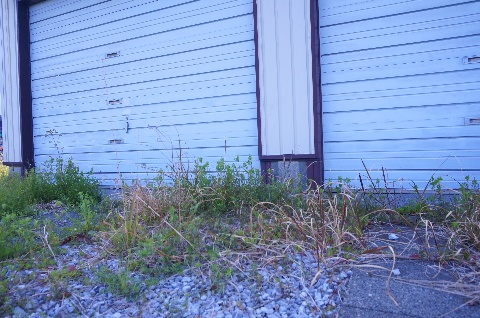

In [7]:
#image=dataset['train'][188]["image"]
image=dataset['train'][15]["image"]
image
#print('image:',image)
#img_sub_path=dataset['train'][0]["img_sub_path"]
#print(img_sub_path)

In [8]:
obj=dataset["train"].features["objects"]
obj
#dataset['train'][188]["objects"]
#obj_one

{'id': List(Value('int64')),
 'area': List(Value('int64')),
 'bbox': List(List(Value('float32'), length=4)),
 'category': List(ClassLabel(names=['zasou', 'tree', 'potted_plant', 'zasou_cluster']))}

In [10]:
objects=dataset['train'][15]['objects']
#obj["category"]
print('objects:',objects)

objects: {'id': [18, 19], 'area': [17762, 6688], 'bbox': [[126.0, 181.0, 214.0, 83.0], [7.0, 177.0, 88.0, 76.0]], 'category': [3, 3]}


In [11]:
#id2label = {0: 'zasou'}
#id2label={0:'zasou',1:'tree',2:'potted_plant'}
#label2id = {'zasou': 0}
#label2id={'zasou':0,'tree':1,'potted_plant':2}

# データセットの全行数を取得
#print(len(dataset))

if False:
    # または属性から直接確認
    #print(dataset.num_rows)   # {'train': 264}
    print(dataset["train"].num_rows)  # 264
    rows=dataset["train"].num_rows
    cat_list=[]
    for i in range(rows):
        category=dataset['train'][i]['objects']['category']
        for cat in category:
            print('cat',cat)
            #if not cat_list[cat]:
            #    cat_list[cat]=cat
        break

#print(dataset["train"].features["objects"])
# パターン1: .feature を経由する（標準的）  --> こちらで、 OK
categories = dataset["train"].features["objects"]["category"].feature.names
#print('categories:',categories)

id2label = {index: x for index, x in enumerate(categories, start=0)}
label2id = {v: k for k, v in id2label.items()}

print('id2label:',id2label)
print('label2id:',label2id)


id2label: {0: 'zasou', 1: 'tree', 2: 'potted_plant', 3: 'zasou_cluster'}
label2id: {'zasou': 0, 'tree': 1, 'potted_plant': 2, 'zasou_cluster': 3}


<class 'dict'>
dict_keys(['image', 'img_sub_path', 'image_id', 'width', 'height', 'objects'])
<class 'dict'>


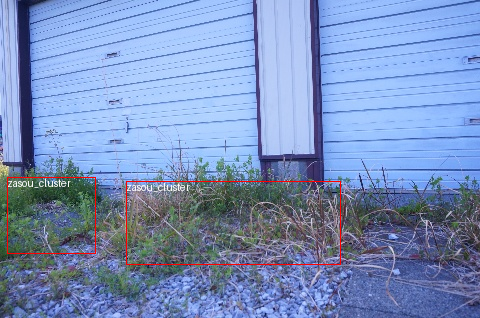

In [12]:
import torch
from torchvision.ops import box_convert
from torchvision.utils import draw_bounding_boxes

from torchvision.transforms.functional import pil_to_tensor, to_pil_image
example = dataset['train'][15]
print(type(example))
print(example.keys())

if True:
    print(type(example))
    image = example["image"]
    annotations = example["objects"]
    draw = ImageDraw.Draw(image)
    #categories = dataset["train"].features["objects"]["category"].feature.names
    #id2label = {index: x for index, x in enumerate(categories, start=0)}
    #label2id = {v: k for k, v in id2label.items()}
    for i in range(len(annotations["id"])):
        box = annotations["bbox"][i]
        class_idx = annotations["category"][i]
        x, y, w, h = tuple(box)
        draw.rectangle((x, y, x + w, y + h), outline="red", width=1)
        draw.text((x, y), id2label[class_idx], fill="white")
image
#example
#dataset['train'][15]

In [13]:
from transformers import AutoImageProcessor
img_checkpoint = "facebook/detr-resnet-50"
#checkpoint = "./detr-resnet-50_finetuned_zasou-2024.7.7-2"
#checkpoint = "./detr-resnet-50_finetuned_zasou-300epoch"
checkpoint = "./detr-resnet-50_finetuned_zasou/checkpoint-7920"
#最新の高速版は、こちら
#image_processor = AutoImageProcessor.from_pretrained(checkpoint)
# 従来版は、こちら
image_processor = AutoImageProcessor.from_pretrained(img_checkpoint,use_fast=False)

# 学習の継続時 = True
Train_Cont=False
if not Train_Cont:
    checkpoint=img_checkpoint


##### 画像の拡張
元画像のアスペクト比を維持してリサイズ(480x480) して、短い辺の余白を、黒(0,0,0) で埋めます。 --> いまは、NG

In [15]:
import albumentations
import numpy as np
import torch

USE_ASPECT_FIX=False

if USE_ASPECT_FIX:
    # アスペクト比を維持させる
    transform = albumentations.Compose(
        [
            # 1. アスペクト比を維持し、長い方の辺を480ピクセルに合わせる
            albumentations.LongestMaxSize(max_size=480),
            # 2. 足りない部分を黒（0）で埋めて 480x480 に固定する
            albumentations.PadIfNeeded(
                min_height=480, 
                min_width=480, 
                border_mode=0, # 定数（黒）で埋める
                #value=(0, 0, 0)
                fill=0  # 'value' を 'fill' に変更（黒にする場合は 0 または [0, 0, 0]）
            ),
            # 3. その他のデータ拡張
            albumentations.HorizontalFlip(p=0.5),
        ],
        # bboxもパディングに合わせて自動で座標調整されます
        bbox_params=albumentations.BboxParams(format="coco", label_fields=["category"]),
    )
else:
    transform = albumentations.Compose(
        [
            albumentations.Resize(480, 480),
            #albumentations.HorizontalFlip(p=1.0),
            # 1.0だと毎回反転するので、0.5（半分）にするのが自然です
            albumentations.HorizontalFlip(p=0.5), 
            #albumentations.RandomBrightnessContrast(p=1.0),
        ],
        bbox_params=albumentations.BboxParams(format="coco", label_fields=["category"]),
    )

image_processor は、注釈が次の形式であることを期待します: {'image_id': int, 'annotations': List[Dict]},   
ここで、各辞書は COCO オブジェクトの注釈です。 1 つの例として、注釈を再フォーマットする関数を追加してみましょう。

In [16]:
def formatted_anns(image_id, category, area, bbox):
    annotations = []
    for i in range(0, len(category)):
        new_ann = {
            "image_id": image_id,     # int
            "category_id": category[i],
            "isCrowd": 0,
            "area": area[i],
            "bbox": list(bbox[i]),
        }
        annotations.append(new_ann)
    return annotations

In [17]:
# transforming a batch
def transform_aug_ann(examples):
    image_ids = examples["image_id"]
    images, bboxes, area, categories = [], [], [], []
    for image, objects in zip(examples["image"], examples["objects"]):
        image = np.array(image.convert("RGB"))[:, :, ::-1]
        out = transform(image=image, bboxes=objects["bbox"], category=objects["category"])
        area.append(objects["area"])
        images.append(out["image"])
        bboxes.append(out["bboxes"])
        categories.append(out["category"])
    targets = [
        {"image_id": id_, "annotations": formatted_anns(id_, cat_, ar_, box_)}
        for id_, cat_, ar_, box_ in zip(image_ids, categories, area, bboxes)
    ]
    return image_processor(images=images, annotations=targets, return_tensors="pt")


In [18]:
dataset['train'] = dataset['train'].with_transform(transform_aug_ann)
#dataset['train'][15]

In [19]:
import torch
from torchvision.ops import box_convert
from torchvision.utils import draw_bounding_boxes

from torchvision.transforms.functional import pil_to_tensor, to_pil_image
example = dataset['train'][15]
print('type(example):',type(example))
print('example.keys():',example.keys())

print("type(example[\'labels\']):",type(example['labels']))
print("example[\'labels\']:",example['labels'])
if False:
    image = to_pil_image(
        draw_bounding_boxes(
            #example["image"],
            example["pixel_values"],
            box_convert(example['labels']['boxes'], 'xywh', 'xyxy'),
            colors='red',
            #labels=[categories.int2str(x) for x in example['category']]
            labels=["zasou"])
    )
    
#example
#dataset['train'][15]

type(example): <class 'dict'>
example.keys(): dict_keys(['pixel_values', 'pixel_mask', 'labels'])
type(example['labels']): <class 'transformers.image_processing_base.BatchFeature'>
example['labels']: {'size': tensor([800, 800]), 'image_id': tensor([15]), 'class_labels': tensor([3, 3]), 'boxes': tensor([[0.5146, 0.6997, 0.4458, 0.2610],
        [0.8938, 0.6761, 0.1833, 0.2390]]), 'area': tensor([49338.8867, 18577.7773]), 'iscrowd': tensor([0, 0]), 'orig_size': tensor([480, 480])}


In [20]:
def collate_fn(batch):
    # item["pixel_values"] は Albumentations 後の NumPy 配列を想定
    pixel_values = [item["pixel_values"] for item in batch]
    # ここでパディングと pixel_mask の作成、Tensor化を一括で行う
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    labels = [item["labels"] for item in batch]
    batch = {}
    batch["pixel_values"] = encoding["pixel_values"]
    batch["pixel_mask"] = encoding["pixel_mask"]
    batch["labels"] = labels
    return batch
    

In [ ]:
Training the DETR model  
学習時に、実際渡される画像を確認します。  
BGR -> RGB でよいのかな?  
サイズ 800x800 で、良いのか?  
detr の本来の入力サイズは、[3,800,800] か?  
要確認!!

--- Dataset Item 15 Debug ---
Pixel Values Shape: torch.Size([3, 800, 800])


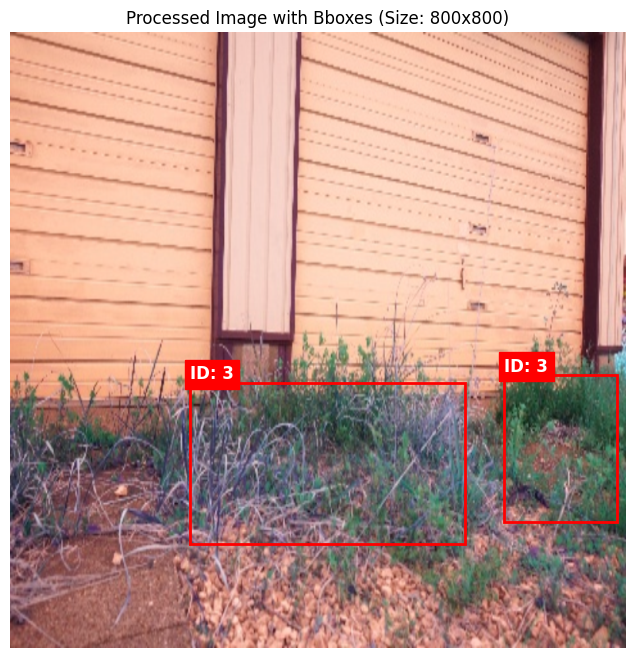

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def debug_dataset_sample(dataset, index=0):
    # 1. データの取り出し
    item = dataset[index]
    
    pixel_values = item["pixel_values"] # torch.Tensor [3, 480, 480]
    labels = item["labels"]
    
    print(f"--- Dataset Item {index} Debug ---")
    print(f"Pixel Values Shape: {pixel_values.shape}")
    print(f"Pixel Values Max: {pixel_values.max():.4f}") # 1.0付近か 255付近か？
    print(f"Pixel Values Min: {pixel_values.min():.4f}") # 0付近か -2.0付近か？
    print(f"Labels: {labels}")

    # 2. 画像の可視化 (Tensor -> numpy)
    # PyTorchは [C, H, W] なので [H, W, C] に戻す
    img = pixel_values.permute(1, 2, 0).numpy()
    
    # 正規化（ImageNet等）されている場合は表示用に 0-1 に戻す
    img = (img - img.min()) / (img.max() - img.min())
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Processed Image (Size: {img.shape[:2]})")
    plt.axis("off")
    plt.show()

def debug_dataset_sample_with_bbox(dataset, index=0):
    # 1. データの取り出し
    item = dataset[index]
    pixel_values = item["pixel_values"] # [3, 480, 480]
    #print('pixel_values.shape:',pixel_values.shape) # torch.Size([3, 800, 800])
    labels = item["labels"]
    
    print(f"--- Dataset Item {index} Debug ---")
    print(f"Pixel Values Shape: {pixel_values.shape}")
    
    # 2. 画像の変換 (Tensor [C,H,W] -> Numpy [H,W,C])
    img = pixel_values.permute(1, 2, 0).numpy()
    # 表示用に 0-1 に正規化
    img = (img - img.min()) / (img.max() - img.min())
    
    h, w = img.shape[:2]
    
    # 3. 描画
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img)

    # 4. ボックスの描画
    bboxes = labels["boxes"]
    for i, bbox in enumerate(bboxes):
        # DETR形式 [center_x, center_y, width, height] (0-1) を座標に変換
        cx, cy, bw, bh = bbox.tolist()
        
        # 左上座標 (x1, y1) を計算
        x1 = (cx - bw / 2) * w
        y1 = (cy - bh / 2) * h
        width = bw * w
        height = bh * h
        
        # 四角形を描画
        rect = patches.Rectangle(
            (x1, y1), width, height, 
            linewidth=2, edgecolor='r', facecolor='none'
        )
        ax.add_patch(rect)
        
        # クラスIDを表示
        class_id = labels["class_labels"][i].item()
        ax.text(x1, y1 - 5, f"ID: {class_id}", color='white', 
                fontsize=12, fontweight='bold', backgroundcolor='red')

    plt.title(f"Processed Image with Bboxes (Size: {w}x{h})")
    plt.axis("off")
    plt.show()

train_dataset=dataset['train']
# 実行
#debug_dataset_sample(train_dataset, index=15)
# 実行
debug_dataset_sample_with_bbox(train_dataset, index=15)


In [ ]:
#from transformers import DetrForObjectDetection
#model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")
#model

In [ ]:
from transformers import AutoModelForObjectDetection
model = AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
#model

learning_rate=1e-5  
300 epoch learning_rate=1.875e-8

In [ ]:
from transformers import TrainingArguments
USE_ARG1=False
USE_ARG2=False
USE_ARG_ORG=True
num_train_epochs=165
if USE_ARG1:
    # こちらは、検証用データが必要
    training_args = TrainingArguments(
        output_dir="detr-resnet-50_finetuned_zasou",
        per_device_train_batch_size=8,
        num_train_epochs=num_train_epochs,
        fp16=True,
        learning_rate=1e-5,
        weight_decay=1e-4,
        save_total_limit=2,
        remove_unused_columns=False,
        push_to_hub=True,
        # --- 追加/変更を検討したい項目 ---
        #evaluation_strategy="epoch",     # エポックごとに評価
        eval_strategy="epoch",       # ← ここを eval_strategy に変更
        save_strategy="epoch",       # (こちらはそのままでも動きますが、推奨は epoch です)
        load_best_model_at_end=True,     # 最良モデルを最後に読み込む
        logging_first_step=True,
        lr_scheduler_type="cosine",      # 学習率を徐々に下げる（精度が安定しやすい）
    )
if USE_ARG2:
    training_args = TrainingArguments(
        output_dir="detr-resnet-50_finetuned_zasou",
        per_device_train_batch_size=8,
        num_train_epochs=num_train_epochs,
        fp16=True,
        learning_rate=1e-5,
        weight_decay=1e-4,
        save_total_limit=2,
        remove_unused_columns=False,
        push_to_hub=True,
        # --- 追加/変更を検討したい項目 ---
        #evaluation_strategy="epoch",     # エポックごとに評価
        eval_strategy="no",       # ← ここを eval_strategy に変更
        save_strategy="epoch",       # (こちらはそのままでも動きますが、推奨は epoch です)
        load_best_model_at_end=False,     # 最良モデルを最後に読み込む
        logging_first_step=True,
        lr_scheduler_type="cosine",      # 学習率を徐々に下げる（精度が安定しやすい）
    )
if USE_ARG_ORG:
    if Train_Cont:
        num_train_epochs=43
        training_args = TrainingArguments(
            output_dir="detr-resnet-50_finetuned_zasou",
            per_device_train_batch_size=8,
            num_train_epochs=num_train_epochs,
            fp16=True,
            learning_rate=1e-5,
            #learning_rate=1.875e-8,
            weight_decay=1e-4,
            save_total_limit=2,
            remove_unused_columns=False,
            push_to_hub=True,
            #warmup_steps=500,
            #save_steps=200,
            save_strategy="epoch",       # (こちらはそのままでも動きますが、推奨は epoch です)
            logging_steps=200,
            logging_first_step=True,
            #lr_scheduler_type="cosine",      # 学習率を徐々に下げる（精度が安定しやすい）
            #lr_scheduler_type= "constant",
            lr_scheduler_type="linear",  # 急激に下げない
            #logging_dir="./logs", # TensorBoardのログディレクトリ
            report_to="tensorboard"
        )
    else:
        #num_train_epochs=165+43
        training_args = TrainingArguments(
            output_dir="detr-resnet-50_finetuned_zasou",
            per_device_train_batch_size=8,
            num_train_epochs=num_train_epochs,
            fp16=True,
            learning_rate=1e-5,
            #learning_rate=1.875e-8,
            weight_decay=1e-4,
            save_total_limit=2,
            remove_unused_columns=False,
            push_to_hub=True,
            #warmup_steps=500,
            #save_steps=200,
            save_strategy="epoch",       # (こちらはそのままでも動きますが、推奨は epoch です)
            logging_steps=200,
            logging_first_step=True,
            #lr_scheduler_type="cosine",      # 学習率を徐々に下げる（精度が安定しやすい）
            lr_scheduler_type= "constant",
            #logging_dir="./logs", # TensorBoardのログディレクトリ
            report_to="tensorboard"
        )


In [ ]:
from transformers import Trainer
if USE_ARG1:
    #print(dataset.num_rows)   # {'train': 264}
    rows=dataset.num_rows['train']
    ratio = 0.8  # 8:2に分ける
    
    # 分割する位置を計算（整数にする必要あり）
    split_point = int(rows * ratio)
    
    # スライスで分割
    train_dt = dataset["train"][:split_point]  # 0からsplit_pointの手前まで
    test_dt = dataset["train"][split_point:]   # split_pointから最後まで
    trainer = Trainer(
        model=model,
        args=training_args,
        data_collator=collate_fn,
        train_dataset=train_dt,
        eval_dataset=test_dt,
        # tokenizer=image_processor,  <-- これを削除
        processing_class=image_processor, # <-- これに変更
    )
else:
    trainer = Trainer(
        model=model,
        args=training_args,
        data_collator=collate_fn,
        train_dataset=dataset["train"],
        # tokenizer=image_processor,  <-- これを削除
        processing_class=image_processor, # <-- これに変更
    )
    

trainer.train()

In [ ]:
#trainer.push_to_hub()
trainer.save_model("./detr-resnet-50_finetuned_zasou/final_model")
image_processor.save_pretrained("./detr-resnet-50_finetuned_zasou/final_model")
